# ทดลองวิธีแก้ข้อมูลไม่สมดุล (Class Imbalance) — Saphondanai

**คำถาม:** คนลาออกมีแค่ 16% ของข้อมูล ควรแก้ความไม่สมดุลด้วยวิธีอื่น (เช่น SMOTE) แทน `scale_pos_weight` ที่ใช้อยู่ไหม

**กติกาการทดลอง (ตั้งก่อนดูผล)**
- ใช้โมเดลและ hyperparameter เดียวกับโมเดลสุดท้าย (`PARAMS` ใน `src/train.py` = `attrition-xgboost-P` v1) เปลี่ยน **แค่วิธีจัดการ imbalance**
- split เดียวกับทีม (80/20, `stratify=y`, seed 42) → train และ test มีคนลาออก 16% เท่ากัน
- **resample เฉพาะ fold ที่ใช้เทรน** ใน CV (5 fold × 3 รอบ บน train) ห้ามทำก่อนแบ่งข้อมูล ไม่อย่างนั้นแถวสังเคราะห์ที่สร้างจากคนใน fold วัดผลจะรั่วเข้าไป (data leakage) และผลจะดีเกินจริง
- **test ไม่ resample และใช้ครั้งเดียวตอนจบ** เพราะต้องสะท้อนสัดส่วนจริงในบริษัท
- threshold ตรึงไว้ที่ 0.5 ตามที่ทีมตัดสินใจ

**วัดอะไร**
- **AUC / PR-AUC** = โมเดลเรียงคนเสี่ยงไว้ก่อนคนไม่เสี่ยงได้ดีแค่ไหน (ไม่ขึ้นกับ threshold) → วัดว่าวิธีนั้นทำให้โมเดล "เก่งขึ้นจริง" ไหม
- **Precision / Recall / F1 ที่ 0.5** = ผลตอนตัดสินว่าลาออก/ไม่ลาออก
- **Brier score** (ยิ่งต่ำยิ่งดี) และ **คะแนนเฉลี่ย เทียบอัตราลาออกจริง** = คะแนนตรงกับความน่าจะเป็นจริงแค่ไหน (calibration) ซึ่งสำคัญกับ `expected_loss` และ Risk Band

In [1]:
import os, sys, warnings
sys.path.append("../src"); sys.path.append("../backend")
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt, numpy as np, pandas as pd
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import average_precision_score, brier_score_loss, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedKFold, cross_val_predict, train_test_split
from xgboost import XGBClassifier

import calibration  # backend/calibration.py ตัวเดียวกับที่ POST /recalibrate ใช้
from clean_pipeline import RAW_FILENAME, TARGET_COLUMN, clean_data, load_raw_data
from feature_pipeline import SELECTED_FEATURES, add_features
from train import PARAMS

OUT = "../docs/model_lab_S"
df = add_features(clean_data(load_raw_data(f"../data/raw/{RAW_FILENAME}")), only=SELECTED_FEATURES)
X, y = df.drop(columns=TARGET_COLUMN).astype(float), df[TARGET_COLUMN]
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)  # เหมือน 04, 05 และ src/train.py
CV = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)
print(f"train {len(ytr)} คน ลาออก {ytr.mean():.1%} | test {len(yte)} คน ลาออก {yte.mean():.1%}")

C = {"blue": "#2a78d6", "orange": "#eb6834", "aqua": "#1baf7a", "muted": "#898781", "grid": "#e1e0d9", "ink": "#0b0b0b", "ink2": "#52514e"}
plt.rcParams.update({"font.family": ["Tahoma"], "axes.edgecolor": "#c3c2b7", "axes.labelcolor": C["ink2"], "xtick.color": C["ink2"],
                     "ytick.color": C["ink2"], "axes.grid": True, "grid.color": C["grid"], "axes.axisbelow": True,
                     "axes.spines.top": False, "axes.spines.right": False, "figure.dpi": 110, "savefig.bbox": "tight"})

2026/10/01 01:08:19 INFO mlflow.agent.hint: Load the `instrumenting-with-mlflow-tracing` skill at D:\CSI\dev ink\employee-attrition-predictor\.venv\Lib\site-packages\mlflow\assistant\skills\instrumenting-with-mlflow-tracing\SKILL.md before writing any tracing code; it ships with this MLflow install. Set MLFLOW_DISABLE_AGENT_HINT=1 to silence this.


train 1176 คน ลาออก 16.2% | test 294 คน ลาออก 16.0%


## 1. วิธีที่เทียบ

| วิธี | ทำอะไร |
| :--- | :--- |
| ไม่ถ่วง | เทรนตรงๆ ไม่แก้อะไร (จุดอ้างอิง) |
| scale_pos_weight (ใช้อยู่) | ถ่วงน้ำหนักคนลาออก ×5.2 (= ไม่ลาออก / ลาออก) |
| sqrt(scale_pos_weight) | ถ่วงครึ่งทาง ×2.3 |
| RandomOverSampler | คัดลอกแถวคนลาออกซ้ำจนเท่ากัน |
| SMOTE | สร้างแถวคนลาออกใหม่โดยสุ่มจุดระหว่างคนลาออกที่ใกล้กัน |
| SMOTETomek | SMOTE แล้วลบคู่ข้ามคลาสที่ชิดกันเกินไปออก |
| RandomUnderSampler | ตัดคนไม่ลาออกทิ้งจนเท่ากัน (เหลือ train ~300 แถว) |

การ resample ใช้ `scale_pos_weight=1` เพื่อไม่ให้แก้ imbalance ซ้ำสองชั้น

In [2]:
SPW = (ytr == 0).sum() / (ytr == 1).sum()
SAMPLERS = {"RandomOverSampler": RandomOverSampler, "SMOTE": SMOTE, "SMOTETomek": SMOTETomek, "RandomUnderSampler": RandomUnderSampler}
WEIGHTS = {"ไม่ถ่วง": 1.0, "scale_pos_weight (ใช้อยู่)": SPW, "sqrt(scale_pos_weight)": np.sqrt(SPW)}
METHODS = list(WEIGHTS) + list(SAMPLERS)

def fit(method, X, y):
    if method in SAMPLERS:
        X, y = SAMPLERS[method](random_state=42).fit_resample(X, y)  # เรียกเฉพาะกับข้อมูลที่ใช้เทรน
    return XGBClassifier(**PARAMS, scale_pos_weight=WEIGHTS.get(method, 1.0), random_state=42, n_jobs=4).fit(X, y)

def score(y, p):
    yp = p >= 0.5
    return {"AUC": roc_auc_score(y, p), "PR-AUC": average_precision_score(y, p), "F1": f1_score(y, yp),
            "Precision": precision_score(y, yp, zero_division=0), "Recall": recall_score(y, yp),
            "Brier": brier_score_loss(y, p), "คะแนนเฉลี่ย": p.mean()}

folds = []
for method in METHODS:
    for i, (a, b) in enumerate(CV.split(Xtr, ytr)):
        p = fit(method, Xtr.iloc[a], ytr.iloc[a]).predict_proba(Xtr.iloc[b])[:, 1]
        folds.append({"วิธี": method, "fold": i, **score(ytr.iloc[b], p)})
folds = pd.DataFrame(folds)
cv_mean = folds.groupby("วิธี", sort=False).mean().drop(columns="fold")
cv_sd = folds.groupby("วิธี", sort=False).std().drop(columns="fold")
print(f"CV บน train (5 fold × 3 รอบ) อัตราลาออกจริง = {ytr.mean():.3f}")
cv_mean.round(3).assign(**{"AUC SD": cv_sd["AUC"].round(3), "F1 SD": cv_sd["F1"].round(3)})

CV บน train (5 fold × 3 รอบ) อัตราลาออกจริง = 0.162


,AUC,PR-AUC,F1,Precision,Recall,Brier,คะแนนเฉลี่ย,AUC SD,F1 SD
วิธี,,,,,,,,,
ไม่ถ่วง,0.835,0.646,0.502,0.804,0.372,0.091,0.158,0.029,0.076
scale_pos_weight (ใช้อยู่),0.827,0.636,0.549,0.474,0.660,0.128,0.315,0.030,0.053
sqrt(scale_pos_weight),0.831,0.638,0.574,0.641,0.525,0.100,0.228,0.030,0.068
RandomOverSampler,0.821,0.621,0.545,0.474,0.646,0.130,0.317,0.035,0.055
SMOTE,0.828,0.643,0.510,0.746,0.393,0.094,0.184,0.030,0.056
SMOTETomek,0.827,0.637,0.513,0.725,0.404,0.095,0.187,0.032,0.088
RandomUnderSampler,0.794,0.549,0.472,0.351,0.725,0.178,0.399,0.030,0.038


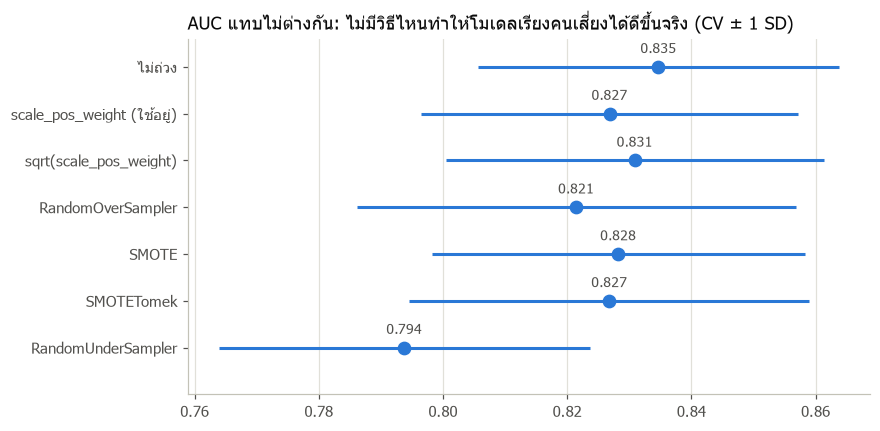

In [3]:
def dot_chart(col, title, fname, ref=None, ref_label=None):
    m, s = cv_mean[col][::-1], cv_sd[col][::-1]
    fig, ax = plt.subplots(figsize=(8, 4.2))
    yy = np.arange(len(m))
    ax.errorbar(m, yy, xerr=s, fmt="o", color=C["blue"], ms=8, lw=2, capsize=0)
    for x, yv in zip(m, yy):
        ax.annotate(f"{x:.3f}", (x, yv), xytext=(0, 9), textcoords="offset points", ha="center", color=C["ink2"], fontsize=9)
    if ref is not None:
        ax.axvline(ref, color=C["orange"], lw=2, ls="--")
        ax.annotate(ref_label, (ref, -0.75), xytext=(6, 0), textcoords="offset points", color=C["orange"], fontsize=9, va="center")
    ax.set_yticks(yy, m.index); ax.grid(axis="y", visible=False); ax.set_ylim(-1, len(m) - 0.4)
    ax.set_title(title, loc="left", color=C["ink"])
    fig.savefig(f"{OUT}/{fname}"); plt.show()

dot_chart("AUC", "AUC แทบไม่ต่างกัน: ไม่มีวิธีไหนทำให้โมเดลเรียงคนเสี่ยงได้ดีขึ้นจริง (CV ± 1 SD)", "imbalance_01_auc.png")

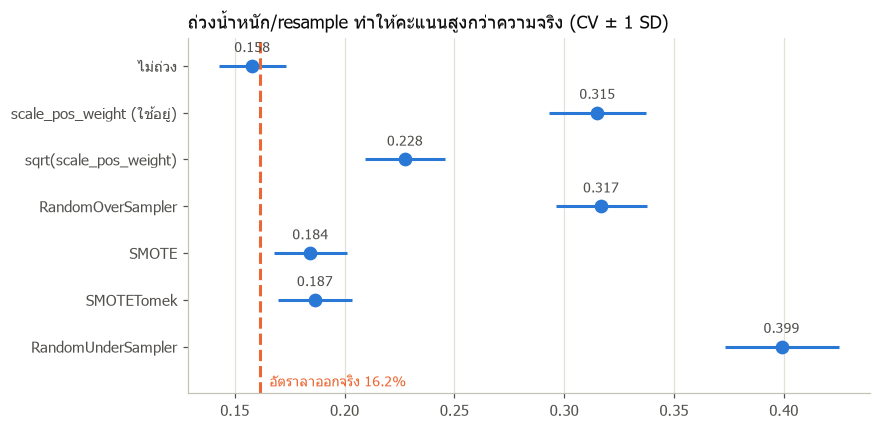

In [4]:
dot_chart("คะแนนเฉลี่ย", "ถ่วงน้ำหนัก/resample ทำให้คะแนนสูงกว่าความจริง (CV ± 1 SD)", "imbalance_02_mean_score.png",
          ref=ytr.mean(), ref_label=f"อัตราลาออกจริง {ytr.mean():.1%}")

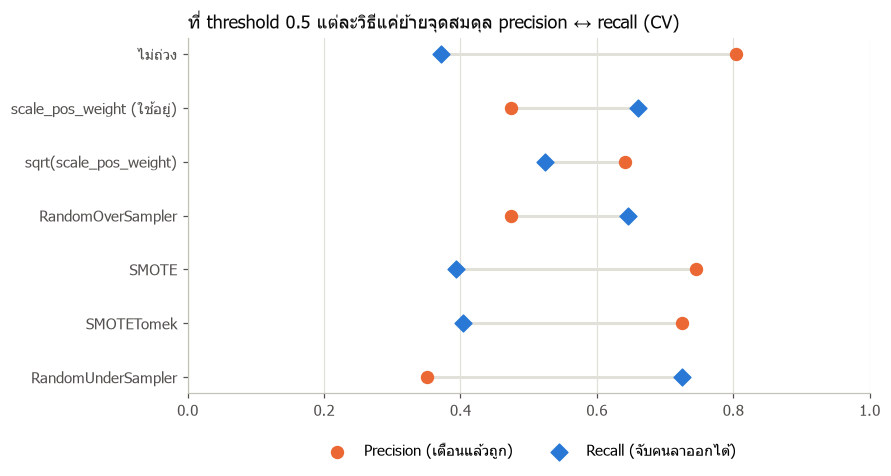

In [5]:
pr = cv_mean[["Precision", "Recall"]][::-1]
fig, ax = plt.subplots(figsize=(8, 4.2))
yy = np.arange(len(pr))
ax.scatter(pr["Precision"], yy, color=C["orange"], s=60, label="Precision (เตือนแล้วถูก)", zorder=3)
ax.scatter(pr["Recall"], yy, color=C["blue"], s=60, marker="D", label="Recall (จับคนลาออกได้)", zorder=3)
ax.hlines(yy, pr.min(axis=1), pr.max(axis=1), color=C["grid"], lw=2)
ax.set_yticks(yy, pr.index); ax.grid(axis="y", visible=False); ax.set_xlim(0, 1)
ax.set_title("ที่ threshold 0.5 แต่ละวิธีแค่ย้ายจุดสมดุล precision ↔ recall (CV)", loc="left", color=C["ink"])
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=2, frameon=False)
fig.savefig(f"{OUT}/imbalance_03_precision_recall.png"); plt.show()

## 2. สาธิต: คง `scale_pos_weight` แล้วปรับคะแนนด้วย `/recalibrate`

ใช้ `backend/calibration.py` ตัวเดียวกับ endpoint จริง (ค่าเริ่มต้น `isotonic`) ในแต่ละ fold: เทรนโมเดลบน fold เทรน → เอาคะแนน out-of-fold **ภายใน** fold เทรนมา fit การปรับเทียบ (จำลองว่าบริษัทส่งข้อมูลย้อนหลังที่มีผลลาออกจริงมาให้) → ใช้กับ fold วัดผล

In [6]:
rows = []
for i, (a, b) in enumerate(CV.split(Xtr, ytr)):
    Xa, ya = Xtr.iloc[a], ytr.iloc[a]
    model = fit("scale_pos_weight (ใช้อยู่)", Xa, ya)
    inner = cross_val_predict(XGBClassifier(**PARAMS, scale_pos_weight=SPW, random_state=42, n_jobs=4), Xa, ya,
                              cv=StratifiedKFold(5, shuffle=True, random_state=i), method="predict_proba")[:, 1]
    p_raw = model.predict_proba(Xtr.iloc[b])[:, 1]
    for method in ("isotonic", "platt"):
        p = calibration.apply({"method": method, "params": calibration.fit(inner, ya.values, method)}, p_raw)
        rows.append({"วิธี": f"scale_pos_weight + recalibrate ({method})", "fold": i, **score(ytr.iloc[b], p)})
calib = pd.DataFrame(rows).groupby("วิธี", sort=False).mean().drop(columns="fold")
pd.concat([cv_mean.loc[["ไม่ถ่วง", "scale_pos_weight (ใช้อยู่)"]], calib]).round(3)

,AUC,PR-AUC,F1,Precision,Recall,Brier,คะแนนเฉลี่ย
วิธี,,,,,,,
ไม่ถ่วง,0.835,0.646,0.502,0.804,0.372,0.091,0.158
scale_pos_weight (ใช้อยู่),0.827,0.636,0.549,0.474,0.660,0.128,0.315
scale_pos_weight + recalibrate (isotonic),0.825,0.596,0.507,0.778,0.389,0.093,0.166
scale_pos_weight + recalibrate (platt),0.827,0.636,0.519,0.812,0.386,0.095,0.166


## 3. ยืนยันบน test (ใช้ครั้งเดียว)

In [7]:
test = pd.DataFrame({m: score(yte, fit(m, Xtr, ytr).predict_proba(Xte)[:, 1]) for m in METHODS}).T
print(f"test {len(yte)} คน ลาออกจริง {int(yte.sum())} คน ({yte.mean():.3f})")
test.round(3)

test 294 คน ลาออกจริง 47 คน (0.160)


,AUC,PR-AUC,F1,Precision,Recall,Brier,คะแนนเฉลี่ย
ไม่ถ่วง,0.805,0.598,0.478,0.800,0.340,0.097,0.156
scale_pos_weight (ใช้อยู่),0.814,0.609,0.488,0.395,0.638,0.135,0.322
sqrt(scale_pos_weight),0.818,0.598,0.565,0.632,0.511,0.105,0.226
RandomOverSampler,0.816,0.595,0.547,0.457,0.681,0.133,0.318
SMOTE,0.821,0.598,0.471,0.762,0.340,0.098,0.177
SMOTETomek,0.817,0.587,0.478,0.800,0.340,0.099,0.175
RandomUnderSampler,0.811,0.602,0.497,0.367,0.766,0.166,0.382


## 4. สรุป

**ผล (CV บน train, ตัวเลขใน test สอดคล้องกัน)**
1. **AUC ของทุกวิธีอยู่ในช่วงเดียวกัน (~0.82–0.835) ห่างกันน้อยกว่า SD ระหว่าง fold** แปลว่าไม่มีวิธีไหนทำให้โมเดลแยกคนลาออกได้เก่งขึ้นจริง ยกเว้น RandomUnderSampler ที่ **แย่ลง** (AUC 0.794, PR-AUC 0.549) เพราะทิ้งข้อมูลไปเกือบ 70%
2. **สิ่งที่แต่ละวิธีเปลี่ยนจริงคือจุดสมดุล precision ↔ recall ที่ threshold 0.5** เช่น `scale_pos_weight` recall 0.66 / precision 0.47 ส่วนไม่ถ่วง recall 0.37 / precision 0.80 ซึ่งเป็นผลแบบเดียวกับการขยับ threshold
3. **SMOTE / SMOTETomek ไม่ได้ช่วย** AUC ไม่ขึ้น recall ต่ำกว่า `scale_pos_weight` มาก และสร้างพนักงานที่ไม่มีอยู่จริง (เช่น `JobLevel` 2.4, one-hot ไม่ใช่ 0/1) ซึ่งทำให้อธิบายผลกับ HR ยากขึ้น
4. **ราคาของการถ่วงน้ำหนัก/resample คือ calibration:** คะแนนเฉลี่ยของ `scale_pos_weight` ≈ 0.32 ขณะที่ลาออกจริง 0.16 (Brier แย่ลง) ส่วนไม่ถ่วงคะแนนเฉลี่ยตรงความจริงพอดี
5. **ทางเลือกของทีมใช้ได้จริง:** `scale_pos_weight` + `/recalibrate` ดึงคะแนนเฉลี่ยจาก 0.315 กลับมาเป็น 0.166 (จริง 0.162) และ Brier จาก 0.128 เหลือ 0.093–0.095 ใกล้โมเดลไม่ถ่วง โดยไม่เปลี่ยนโมเดล ไม่เปลี่ยน SHAP
   - `platt` คงลำดับคะแนนเดิมทุกคน (PR-AUC 0.636 เท่าเดิม) ส่วน `isotonic` (ค่าเริ่มต้นของ endpoint) ทำให้คะแนนหลายคนเท่ากันเป็นขั้นบันได PR-AUC ลดเหลือ 0.596 ถ้าข้อมูลของบริษัทมีน้อย `platt` น่าจะเหมาะกว่า
   - หลังปรับเทียบ recall ที่ 0.5 ลดเหลือ ~0.39 (เท่าโมเดลไม่ถ่วง) เพราะคะแนนลดลงมาตรงความจริง ผลนี้คาดไว้แล้ว: การถ่วงน้ำหนักกับการปรับเทียบหักล้างกัน
6. `sqrt(scale_pos_weight)` ได้ F1 สูงสุดใน CV แต่ห่างจากตัวที่ใช้อยู่ไม่เกิน 1 SD ของ F1 จึงไม่ถือว่าดีกว่าอย่างมีนัยสำคัญ

**ข้อสรุปของทีม: คง `scale_pos_weight` (โมเดล `attrition-xgboost-P` v1) + threshold 0.5 และใช้ `/recalibrate` ปรับคะแนนเมื่อบริษัทมีข้อมูลจริง** เพราะ recall ที่สูงเหมาะกับงาน HR ที่พลาดคนจะลาออกแพงกว่าการเตือนเกิน ส่วนปัญหาคะแนนสูงเกินจริงแก้ได้ด้วย calibration ที่มีในระบบอยู่แล้ว

**ข้อควรระวังเมื่อ recalibrate แล้ว:** คะแนนจะลดลงมาตรงความจริง คนที่ถูกจัดเป็น High (≥ 0.7) จะน้อยลงมาก ถ้าจะใช้ Risk Band กับคะแนนที่ปรับแล้ว ควรทบทวนเกณฑ์ 0.4 / 0.7 ร่วมกับทีม

**อ้างอิง**
- van den Goorbergh R. et al. (2022). *The harm of class imbalance corrections for risk prediction models.* JAMIA 29(9).
- Elor Y. & Averbuch-Elor H. (2022). *To SMOTE, or not to SMOTE?* arXiv:2201.08528.
- Chawla N. et al. (2002). *SMOTE: Synthetic Minority Over-sampling Technique.* JAIR 16.

## 5. ตัวชี้วัดหลักของโมเดลสุดท้าย พร้อมช่วงความเชื่อมั่น (bootstrap)

test มีคนลาออกแค่ 47 คน ตัวเลขเดี่ยวจึงแกว่งได้มาก คำนวณช่วงความเชื่อมั่น 95% โดยสุ่มแถวของ test ซ้ำแบบใส่คืน 1,000 รอบ (โมเดลเดิม ไม่เทรนใหม่) แล้วดูเปอร์เซ็นไทล์ 2.5 และ 97.5

| ชั้น | ตัวชี้วัด | บอกอะไร |
| :--- | :--- | :--- |
| ความแม่นของโมเดล | ROC AUC, PR-AUC | เรียงคนเสี่ยงไว้ก่อนคนไม่เสี่ยงได้ดีแค่ไหน (PR-AUC ถ้าเดาสุ่ม = อัตราลาออก 0.16) |
| ประโยชน์ที่ HR ได้ | Recall@top20% | ถ้า HR ดูแล 20% ที่คะแนนสูงสุด จะครอบคลุมคนที่จะลาออกจริงกี่ % (สุ่มได้ 20%) |
| | Recall / Precision ที่ 0.5 | ผลที่ threshold ที่ทีมใช้ |
| ความน่าเชื่อของคะแนน | Brier | คะแนนตรงกับความน่าจะเป็นจริงแค่ไหน (ก่อน recalibrate) |

ไม่ใช้ Accuracy เป็นตัวหลัก เพราะทายว่าไม่มีใครลาออกก็ได้ 84% แล้ว

In [8]:
def recall_at_top(y, p, frac=0.2):  # นิยามเดียวกับ notebook 04
    top = np.argsort(-p)[: int(len(p) * frac)]
    return y[top].sum() / y.sum()

def headline(y, p):
    return {"ROC AUC": roc_auc_score(y, p), "PR-AUC": average_precision_score(y, p), "Recall@top20%": recall_at_top(y, p),
            "Recall@0.5": recall_score(y, p >= 0.5), "Precision@0.5": precision_score(y, p >= 0.5), "Brier": brier_score_loss(y, p)}

p_final = fit("scale_pos_weight (ใช้อยู่)", Xtr, ytr).predict_proba(Xte)[:, 1]  # = attrition-xgboost-P v1
yv = yte.to_numpy()
rng = np.random.default_rng(42)
boots = pd.DataFrame([headline(yv[i], p_final[i]) for i in (rng.integers(0, len(yv), len(yv)) for _ in range(1000))])
print(f"test {len(yv)} คน ลาออกจริง {int(yv.sum())} คน | bootstrap 1,000 รอบ")
pd.DataFrame({"test": headline(yv, p_final), "CI 2.5%": boots.quantile(0.025), "CI 97.5%": boots.quantile(0.975)}).round(3)

test 294 คน ลาออกจริง 47 คน | bootstrap 1,000 รอบ


,test,CI 2.5%,CI 97.5%
ROC AUC,0.814,0.733,0.887
PR-AUC,0.609,0.468,0.739
Recall@top20%,0.596,0.446,0.714
Recall@0.5,0.638,0.500,0.789
Precision@0.5,0.395,0.287,0.507
Brier,0.135,0.114,0.156
